In [3]:
import pandas as pd
gender_classification="C:\\Users\\ACER\\Downloads\\gender_classification.csv"
df=pd.read_csv(gender_classification)
print(df)
#checking null values
print("Missing Value:\n",df.isnull().sum())

      long_hair  forehead_width_cm  forehead_height_cm  nose_wide  nose_long  \
0             1               11.8                 6.1          1          0   
1             0               14.0                 5.4          0          0   
2             0               11.8                 6.3          1          1   
3             0               14.4                 6.1          0          1   
4             1               13.5                 5.9          0          0   
...         ...                ...                 ...        ...        ...   
4996          1               13.6                 5.1          0          0   
4997          1               11.9                 5.4          0          0   
4998          1               12.9                 5.7          0          0   
4999          1               13.2                 6.2          0          0   
5000          1               15.4                 5.4          1          1   

      lips_thin  distance_nose_to_lip_l

In [4]:
#checking the duplicates
print("Duplicates:\n",df.duplicated().sum())

Duplicates:
 1768


In [5]:
#remove duplicates
df=df.drop_duplicates()
print(df)

      long_hair  forehead_width_cm  forehead_height_cm  nose_wide  nose_long  \
0             1               11.8                 6.1          1          0   
1             0               14.0                 5.4          0          0   
2             0               11.8                 6.3          1          1   
3             0               14.4                 6.1          0          1   
4             1               13.5                 5.9          0          0   
...         ...                ...                 ...        ...        ...   
4986          1               11.7                 6.1          1          1   
4990          1               12.6                 5.7          0          0   
4992          1               14.1                 7.0          1          1   
4993          1               11.6                 5.9          0          0   
4995          1               12.3                 6.9          0          1   

      lips_thin  distance_nose_to_lip_l

In [6]:
print("Duplicates:\n",df.duplicated().sum())

Duplicates:
 0


In [7]:
#preprocessing
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df["gender"] = le.fit_transform(df["gender"])
x=df.drop("gender",axis=1)
y=df["gender"]

In [8]:
#splitting dataset
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [9]:
#import model and train model
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [10]:
#evaluate model
y_pred=lr.predict(x_test)
from sklearn.metrics import accuracy_score,classification_report
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)
print("Classification Report:\n",classification_report(y_test, y_pred,target_names=["Female","Male"]))

Accuracy: 0.9556701030927836
Classification Report:
               precision    recall  f1-score   support

      Female       0.96      0.95      0.95       457
        Male       0.96      0.96      0.96       513

    accuracy                           0.96       970
   macro avg       0.96      0.96      0.96       970
weighted avg       0.96      0.96      0.96       970



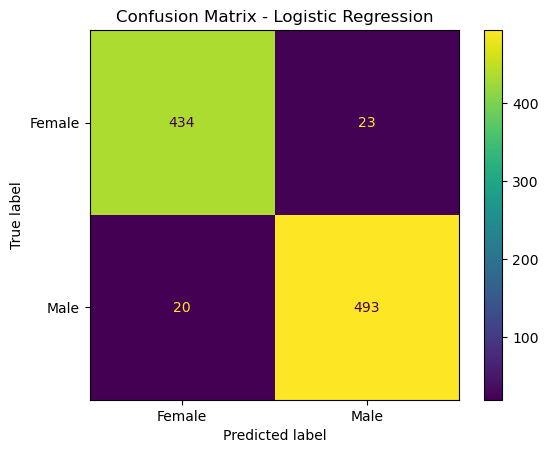

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Female", "Male"])
disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [12]:
#external data
new_data = [[0, 14, 8.2, 1, 0, 0, 0]] 

new_data_df = pd.DataFrame(new_data, columns=x.columns)

log_result = lr.predict(new_data_df)[0]
print("Logistic Regression:", le.inverse_transform([log_result])[0])


Logistic Regression: Female


     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     ...   ... 

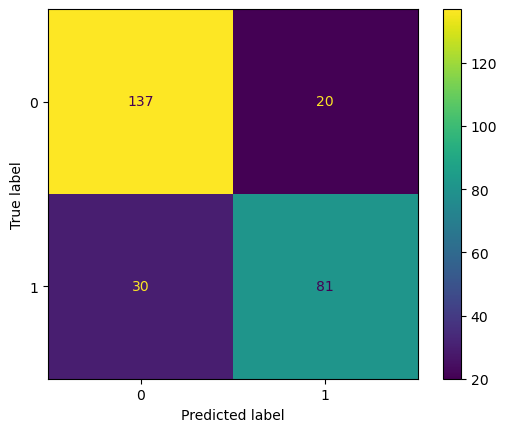

Prediction for External Data: [0]
Passenger Did Not Survive


In [13]:
#Titanic dataset
import pandas as pd

# load dataset
titanic = "C:\\Users\\ACER\\Downloads\\titanic.csv"

df = pd.read_csv(titanic)

print(df)

# checking null values
print("Missing Values:\n", df.isnull().sum())

# checking duplicates
print("Duplicates:\n", df.duplicated().sum())

# remove duplicates
df = df.drop_duplicates()

print("Duplicates After Removing:\n", df.duplicated().sum())

# fill missing values
df["Age"] = df["Age"].fillna(df["Age"].median())

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# preprocessing
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Sex"] = le.fit_transform(df["Sex"])

df["Embarked"] = le.fit_transform(df["Embarked"])

# input and output
x = df[["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]]
y = df["Survived"]

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42
)

# import model
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

# train model
lr.fit(x_train, y_train)

# prediction
y_pred = lr.predict(x_test)

# evaluate model
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print(classification_report(y_test, y_pred))

# confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:\n", cm)

# display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.show()

# external data prediction
external_data = pd.DataFrame({
    "Pclass": [3],
    "Sex": [1],
    "Age": [22],
    "SibSp": [1],
    "Parch": [0],
    "Fare": [7.25],
    "Embarked": [2]
})

prediction = lr.predict(external_data)

print("Prediction for External Data:", prediction)

if prediction[0] == 1:
    print("Passenger Survived")
else:
    print("Passenger Did Not Survive")